# Notebook 12 - Normalizing Flow using handcrafted Features

**Research Question : Can Normalizing Flow outperform handcrafted-feature Autoencoder?**

# 1. Setup

This notebook evaluates **Normalizing Flows** for unsupervised machine audio anomaly detection using the selected handcrafted acoustic features developed in the previous notebooks.

To ensure a fair comparison, the dataset, train/test split, feature preprocessing, and evaluation protocol remain identical to Notebook 11. The only change is the anomaly detection model, replacing the Autoencoder with a RealNVP-based Normalizing Flow implemented using the `nflows` library.

In [1]:
# Imports
import warnings
warnings.filterwarnings("ignore")
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)


# Normalizing Flow
from nflows.distributions.normal import StandardNormal
from nflows.flows.base import Flow
from nflows.transforms.base import CompositeTransform
from nflows.transforms.permutations import RandomPermutation
from nflows.transforms.coupling import AffineCouplingTransform
from nflows.nn.nets import ResidualNet


from src.config import *
from src.dataset import (dataset_summary)
from src.utils import (set_seed)
from src.visualization import (
    plot_histogram,
    plot_boxplot
)

In [2]:
# Experiment Configuration
CONFIG = {
    # Dataset
    "feature_csv": os.path.join(
        results_path,
        "selected_features.csv"
    ),
    "split_csv": os.path.join(
        results_path, 
        "experiment_split.csv"
    ),
    # Flow Architecture
    "num_flow_steps": 6,
    "hidden_features": 64,
    "num_blocks": 2,

    # Training
    "batch_size": 64,
    "epochs": 50,
    "learning_rate": 1e-3,

    # Misc
    "random_seed": random_seed

}

In [3]:
# Reproducibility
set_seed(CONFIG["random_seed"])

In [4]:
# Device
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device : {device}")

Device : cuda


In [5]:
# Display Configuration
pd.set_option("display.max_columns", None)
plt.style.use("default")
sns.set_theme(style="whitegrid")

In [6]:

# Verify Environment

print("=" * 60)
print("Notebook 12 : Normalizing Flow")
print("=" * 60)
print(f"Machine        : {machine}")
print(f"Machine ID     : {machine_id}")
print(f"Channel        : {channel}")
print(f"Random Seed    : {CONFIG['random_seed']}")
print(f"Device         : {device}")
print("=" * 60)

Notebook 12 : Normalizing Flow
Machine        : Pump
Machine ID     : id_00
Channel        : 0
Random Seed    : 42
Device         : cuda


# 2. Load Handcrafted Feature Dataset

The handcrafted feature dataset generated during the feature engineering stage is used as the input representation for the Normalizing Flow model.


In [7]:
feature_df = pd.read_csv(CONFIG["feature_csv"])
split_df = pd.read_csv(CONFIG["split_csv"])
print(feature_df.shape)
print(split_df.shape)

(1149, 12)
(1149, 4)


In [8]:
feature_df = feature_df.merge(
    split_df,
    on=[
        "file_name",
        "label",
        "Research_Group"
    ],
    how="inner"
)

In [9]:
print(feature_df.shape)
feature_df.head()

(1149, 13)


,file_name,label,Research_Group,rms,mfcc_1_mean,mfcc_1_std,mfcc_2_mean,mfcc_2_std,mfcc_5_std,mfcc_8_mean,centroid_std,centroid_iqr,split
0,00000000.wav,Normal,Normal,0.006863,-285.32410,13.046962,61.081543,8.571634,6.616282,1.595431,203.249647,252.325257,train
1,00000001.wav,Normal,Normal,0.006892,-282.27840,10.958236,51.239525,7.887704,7.068424,-0.574502,163.012387,196.780913,train
2,00000002.wav,Normal,Normal,0.007001,-284.63037,13.951112,60.277317,10.349363,6.943223,2.044545,221.444349,277.055284,train
3,00000003.wav,Normal,Normal,0.006864,-284.53845,11.082034,51.455030,7.180773,5.265297,3.684129,143.981090,175.194813,train
4,00000004.wav,Normal,Normal,0.006833,-281.46950,10.882649,63.417408,7.536225,5.741307,1.347923,161.885214,178.263960,train


In [10]:
# Selected Feature Columns
excluded_columns = [
    "file_name",
    "label",
    "Research_Group",
    "split"
]
selected_features = [
    column
    for column in feature_df.columns
    if column not in excluded_columns
]
print(f"Selected Features ({len(selected_features)})")
selected_features

Selected Features (9)


['rms',
 'mfcc_1_mean',
 'mfcc_1_std',
 'mfcc_2_mean',
 'mfcc_2_std',
 'mfcc_5_std',
 'mfcc_8_mean',
 'centroid_std',
 'centroid_iqr']

In [11]:
# Feature Statistics
feature_df.to_csv(results_path/"benchmark_split.csv")

In [12]:
# Verify Split
feature_df["split"].value_counts()

split
train    863
test     286
Name: count, dtype: int64

### Separate Train and Test Sets

In [13]:
train_df = feature_df[
    feature_df["split"] == "train"
].reset_index(drop=True)

test_df = feature_df[
    feature_df["split"] == "test"
].reset_index(drop=True)

print(f"Training Recordings : {len(train_df)}")
print(f"Testing Recordings  : {len(test_df)}")

Training Recordings : 863
Testing Recordings  : 286


In [14]:
# Verify Label Distribution
print("Training Labels")
display(train_df["label"].value_counts())
print()
print("Testing Labels")
display(test_df["label"].value_counts())

Training Labels


label
Normal    863
Name: count, dtype: int64


Testing Labels


label
Normal      143
Abnormal    143
Name: count, dtype: int64

# 3. Data Preparation

In [15]:
# Extract Features and Labels
x_train = train_df[selected_features].values
x_test = test_df[selected_features].values
y_test = (
    test_df["label"]
    .map({"Normal": 0, "Abnormal": 1})
    .values
)
research_groups = test_df["Research_Group"].values
print(f"Training Shape : {x_train.shape}")
print(f"Testing Shape  : {x_test.shape}")

Training Shape : (863, 9)
Testing Shape  : (286, 9)


### Feature Standardization

In [16]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [17]:
# Verification
print("Training Feature Statistics")
print(f"Mean : {x_train.mean():.4f}")
print(f"Std  : {x_train.std():.4f}")

Training Feature Statistics
Mean : -0.0000
Std  : 1.0000


### Numpy to PyTorch Tensor

In [18]:
x_train_tensor = torch.tensor(
    x_train,
    dtype=torch.float32
)
x_test_tensor = torch.tensor(
    x_test,
    dtype=torch.float32
)

### TensorDataset

In [19]:
train_dataset = TensorDataset(
    x_train_tensor
)

### DataLoader

In [20]:
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    drop_last=False
)

In [21]:
# Verify Batch Dimensions
sample_batch = next(iter(train_loader))[0]
print("Batch Shape :", sample_batch.shape)

Batch Shape : torch.Size([64, 9])


In [22]:
# Experiment Objects
experiment = {
    "scaler": scaler,
    "selected_features": selected_features,
    "input_dim": x_train.shape[1]
}
print("Input Dimension :", experiment["input_dim"])

Input Dimension : 9


# Part 4 - Building the Normalizing Flow


Unlike the Autoencoder, which learns to reconstruct normal samples, a Normalizing Flow learns the probability density of the training data.

The model consists of a sequence of affine coupling layers separated by random permutations. During training, the flow transforms the handcrafted feature vectors into a latent Gaussian distribution by maximizing their likelihood.

At inference time, recordings with low likelihood (high negative log-likelihood) are considered anomalous.

In [23]:
# Flow Configuration
input_dim = experiment["input_dim"]
print(f"Input Dimension : {input_dim}")
print(f"Flow Steps      : {CONFIG['num_flow_steps']}")
print(f"Hidden Features : {CONFIG['hidden_features']}")

Input Dimension : 9
Flow Steps      : 6
Hidden Features : 64


### Coupling Network Constructor

In [24]:
def create_resnet(in_features, out_features):
    return ResidualNet(
        in_features = in_features,
        out_features = out_features,
        hidden_features = CONFIG["hidden_features"],
        num_blocks = CONFIG["num_blocks"],
        activation = torch.relu,
        dropout_probability = 0.0,
        use_batch_norm = False
    )

### Build Flow Trandform

In [25]:
from nflows.transforms import CompositeTransform
from nflows.transforms import RandomPermutation
from nflows.transforms.coupling import AffineCouplingTransform

transforms = []
for _ in range(CONFIG["num_flow_steps"]):
    transforms.append(
        RandomPermutation(features=input_dim)
    )
    mask = torch.arange(input_dim) % 2
    transforms.append(
        AffineCouplingTransform(
            mask=mask,
            transform_net_create_fn=create_resnet
        )
    )
transform = CompositeTransform(transforms)

### Base distribution

In [26]:

base_distribution = StandardNormal(
    shape=[input_dim]
)

### Normalizing Flow

In [27]:
flow = Flow(
    transform,
    base_distribution
).to(device)

### Optimizer

In [28]:
# Optimizer
optimizer = torch.optim.Adam(
    flow.parameters(),
    lr=CONFIG["learning_rate"]
)

In [29]:
print(flow)

Flow(
  (_transform): CompositeTransform(
    (_transforms): ModuleList(
      (0): RandomPermutation()
      (1): AffineCouplingTransform(
        (transform_net): ResidualNet(
          (initial_layer): Linear(in_features=5, out_features=64, bias=True)
          (blocks): ModuleList(
            (0-1): 2 x ResidualBlock(
              (linear_layers): ModuleList(
                (0-1): 2 x Linear(in_features=64, out_features=64, bias=True)
              )
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (final_layer): Linear(in_features=64, out_features=8, bias=True)
        )
      )
      (2): RandomPermutation()
      (3): AffineCouplingTransform(
        (transform_net): ResidualNet(
          (initial_layer): Linear(in_features=5, out_features=64, bias=True)
          (blocks): ModuleList(
            (0-1): 2 x ResidualBlock(
              (linear_layers): ModuleList(
                (0-1): 2 x Linear(in_features=64, out_features=64, bi

### Number of Parameters

In [30]:
total_params = sum(
    p.numel()
    for p in flow.parameters()
)
trainable_params = sum(
    p.numel()
    for p in flow.parameters()
    if p.requires_grad
)
print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 105,264
Trainable Parameters : 105,264


### Forward Pass test

In [31]:
sample_batch = next(iter(train_loader))[0].to(device)
with torch.no_grad():
    log_prob = flow.log_prob(sample_batch)
    
print(f"Input Shape     : {sample_batch.shape}")
print(f"Output Shape    : {log_prob.shape}")
print(f"Mean Log Prob   : {log_prob.mean():.4f}")

Input Shape     : torch.Size([64, 9])
Output Shape    : torch.Size([64])
Mean Log Prob   : -14.7117


# 5. Model Training

In [32]:
# Training Configuration
train_losses = []
best_loss = np.inf
best_model_path = os.path.join(
    results_path,
    "normalizing_flow.pth"
)

### Training Loop

In [33]:
flow.train()
for epoch in range(CONFIG["epochs"]):
    epoch_loss = 0.0
    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1:02d}/{CONFIG['epochs']}",
        leave=False
    )

    for (batch,) in progress_bar:
        batch = batch.to(device)
        optimizer.zero_grad()

        # Negative Log Likelihood
        loss = -flow.log_prob(batch).mean()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * batch.size(0)
        progress_bar.set_postfix(
            Loss=f"{loss.item():.4f}"
        )

    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1:02d}/{CONFIG['epochs']}] "
        f"Training Loss : {epoch_loss:.4f}"
    )

    # Save best model
    if epoch_loss < best_loss:
        best_loss = epoch_loss

        torch.save(
            flow.state_dict(),
            best_model_path
        )

Epoch 01/50:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch [01/50] Training Loss : 13.3298


Epoch 02/50:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch [02/50] Training Loss : 11.9720


Epoch 03/50:   0%|          | 0/14 [00:00<?, ?it/s]

...

Epoch [48/50] Training Loss : 9.3529


Epoch 49/50:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch [49/50] Training Loss : 9.3089


Epoch 50/50:   0%|          | 0/14 [00:00<?, ?it/s]

Epoch [50/50] Training Loss : 9.2788


### Load the best Model

In [34]:
flow.load_state_dict(
    torch.load(
        best_model_path,
        map_location=device
    )
)

flow.eval()
print("Best model loaded successfully.")

Best model loaded successfully.


### Training Curve

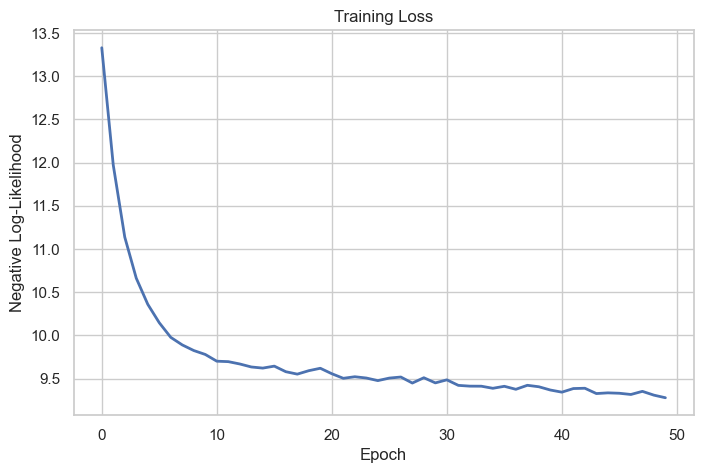

In [35]:
plt.figure(figsize=(8,5))
plt.plot(
    train_losses,
    linewidth=2
)
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Training Loss")
plt.grid(True)
plt.show()

In [36]:
# Training Summary
print("=" * 60)
print(f"Epochs          : {CONFIG['epochs']}")
print(f"Batch Size      : {CONFIG['batch_size']}")
print(f"Learning Rate   : {CONFIG['learning_rate']}")
print(f"Best Loss       : {best_loss:.4f}")
print(f"Model Saved To  : {best_model_path}")
print("=" * 60)

Epochs          : 50
Batch Size      : 64
Learning Rate   : 0.001
Best Loss       : 9.2788
Model Saved To  : C:\MyProjects\MIMIIResearch\EchoGuard\results\normalizing_flow.pth


# 6. Model Evaluation

The trained Normalizing Flow is evaluated using the same experimental protocol as the Autoencoder.

For each recording, the handcrafted feature vectors are passed through the flow model to compute their log-likelihood. The anomaly score for a recording is defined as the average negative log-likelihood (NLL) of all feature vectors extracted from that recording.

Higher NLL indicates that the recording is less likely to belong to the learned distribution of normal machine behaviour and is therefore more likely to be anomalous.

### Computation of Anomaly Scores

In [37]:
flow.eval()
anomaly_scores = []

with torch.no_grad():

    for _, row in tqdm(
        test_df.iterrows(),
        total=len(test_df),
        desc="Evaluating"
    ):

        # Feature vector (9 handcrafted features)
        feature_vector = row[selected_features].values.astype(np.float32)
        
        # Apply the same scaler used during training
        feature_vector = scaler.transform(
            feature_vector.reshape(1, -1)
        )

        # Convert to tensor
        feature_tensor = torch.from_numpy(
            feature_vector
        ).to(device)

        # Negative Log-Likelihood
        nll = -flow.log_prob(feature_tensor)

        anomaly_scores.append(
            nll.item()
        )

anomaly_scores = np.array(anomaly_scores)

print("Evaluation complete.")

Evaluating:   0%|          | 0/286 [00:00<?, ?it/s]

Evaluation complete.


### ROC Curve

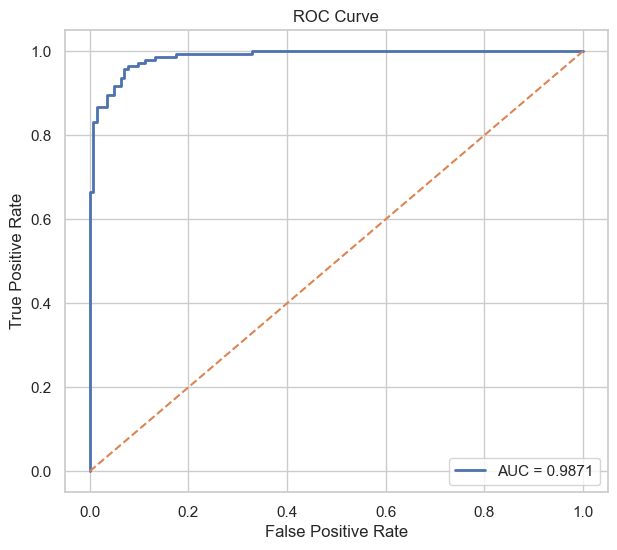

ROC-AUC : 0.9871


In [38]:
roc_auc = roc_auc_score(y_test, anomaly_scores)

fpr, tpr, thresholds = roc_curve(y_test, anomaly_scores)

plt.figure(figsize=(7,6))
plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()
print(f"ROC-AUC : {roc_auc:.4f}")

### Distribution of Anomaly Score

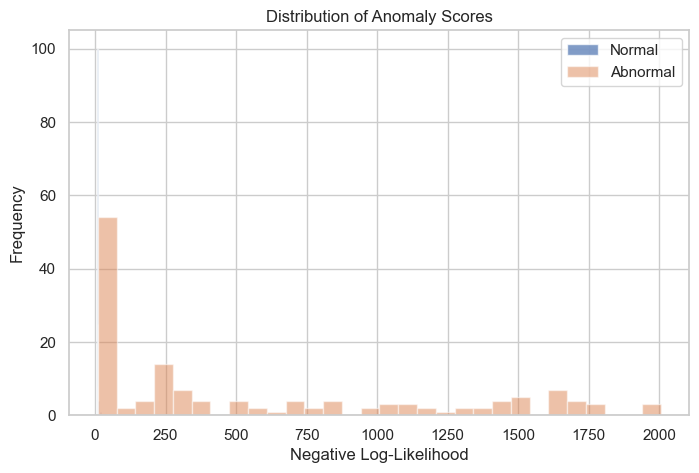

In [47]:
normal_scores = anomaly_scores[y_test == 0]
abnormal_scores = anomaly_scores[y_test == 1]

plt.figure(figsize=(8,5))
plt.hist(
    normal_scores,
    bins=30,
    alpha=0.7,
    label="Normal"
)

plt.hist(
    abnormal_scores,
    bins=30,
    alpha=0.5,
    label="Abnormal"
)

plt.xlabel("Negative Log-Likelihood")
plt.ylabel("Frequency")
plt.title("Distribution of Anomaly Scores")
plt.legend()
plt.show()

### Normal vs Abnormal

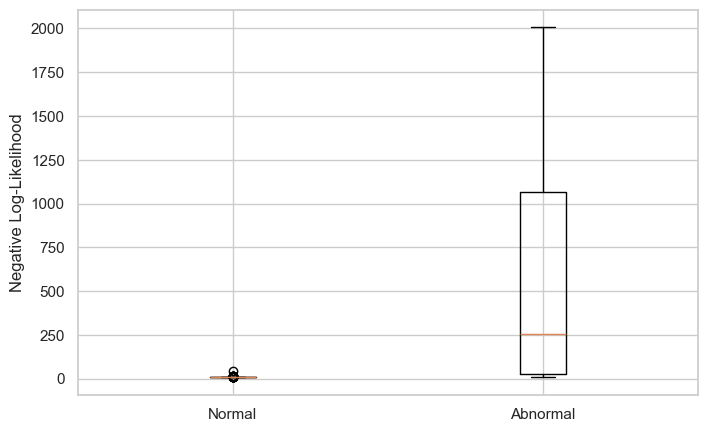

In [50]:
plot_boxplot(
    data=[normal_scores, abnormal_scores],
    labels=["Normal", "Abnormal"], ylabel="Negative Log-Likelihood"
)

### Research Group Analysis

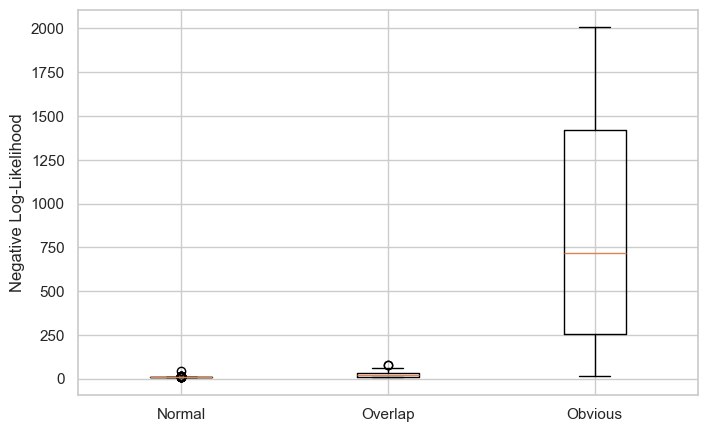

In [54]:
normal_group = anomaly_scores[research_groups == "Normal"]

overlap_group = anomaly_scores[research_groups == "Overlap"]

obvious_group = anomaly_scores[research_groups == "Obvious"]

plot_boxplot(
    data=[normal_group, overlap_group, obvious_group],
    labels=["Normal", "Overlap", "Obvious"],
    ylabel="Negative Log-Likelihood",
)

### Evaluation Summary

In [52]:
print("="*60)
print(f"ROC-AUC : {roc_auc:.4f}")
print(f"Normal Mean Score    : {anomaly_scores[y_test==0].mean():.4f}")
print(f"Abnormal Mean Score  : {anomaly_scores[y_test==1].mean():.4f}")
print("="*60)

ROC-AUC : 0.9871
Normal Mean Score    : 9.9540
Abnormal Mean Score  : 568.4927


| Aspect          | Log-Mel AE     | Handcrafted AE | Handcrafted NF          |
| --------------- | -------------- | -------------- | ----------------------- |
| ROC-AUC         | 0.683          | 0.980          | 0.9871                  |
| Input Dimension | 320            | 9              | 9                       |
| Training Time   | 10–15 min      | 1–2 min        | 1–2 min                 |
| Parameters      | 50,760         | 9,996          | 105,264              |
| Anomaly Score   | Reconstruction | Reconstruction | Negative Log-Likelihood |
